**1. We are interested in finding optimal number of groups for this dataset, where the ground truth grouping information is represented by `sensor location’ feature.**


**a. What method shall we use for solving this problem and why?**

To find the optimal number of clusters we have dropped all rows that have missing data, this ensured that the data we were working with had complete values for all selected features. We took all the columns of numerical data and placed them within a variable (features), normalised the data so to make it easier to compare them all, then applied the KMeans clustering algorithm to group the data. We then used the Elbow method to find the optimal number of clusters which came out to be **5**.

In [5]:
import pandas as pd

df = pd.read_csv('microclimate-sensors-data.csv')

df.head()

,Device_id,Time,SensorLocation,LatLong,MinimumWindDirection,AverageWindDirection,MaximumWindDirection,MinimumWindSpeed,AverageWindSpeed,GustWindSpeed,AirTemperature,RelativeHumidity,AtmosphericPressure,PM25,PM10,Noise
0,ICTMicroclimate-02,2024-09-22T03:13:45+10:00,101 Collins St L11 Rooftop,"-37.814604, 144.9702991",9.0,163.0,300.0,0.3,1.4,1.9,13.2,69.5,1005.3,2.0,4.0,69.1
1,ICTMicroclimate-04,2024-09-22T03:10:14+10:00,Batman Park,"-37.8221828, 144.9562225",0.0,276.0,345.0,0.0,1.4,2.6,12.9,65.1,1013.1,2.0,2.0,73.4
2,ICTMicroclimate-06,2024-09-22T03:20:48+10:00,Tram Stop 7B - Melbourne Tennis Centre Precinc...,"-37.8194993, 144.9787211",0.0,17.0,358.0,0.0,1.6,4.6,12.5,66.8,1009.9,1.0,1.0,61.3
3,ICTMicroclimate-03,2024-09-22T03:22:18+10:00,CH1 rooftop,"-37.8140348, 144.96728",0.0,352.0,319.0,0.0,0.7,1.1,12.6,71.7,1004.5,1.0,5.0,68.6
4,ICTMicroclimate-08,2024-09-22T03:26:32+10:00,Swanston St - Tram Stop 13 adjacent Federation...,"-37.8184515, 144.9678474",0.0,312.0,356.0,0.0,0.7,1.9,13.0,64.3,1010.1,1.0,2.0,58.5


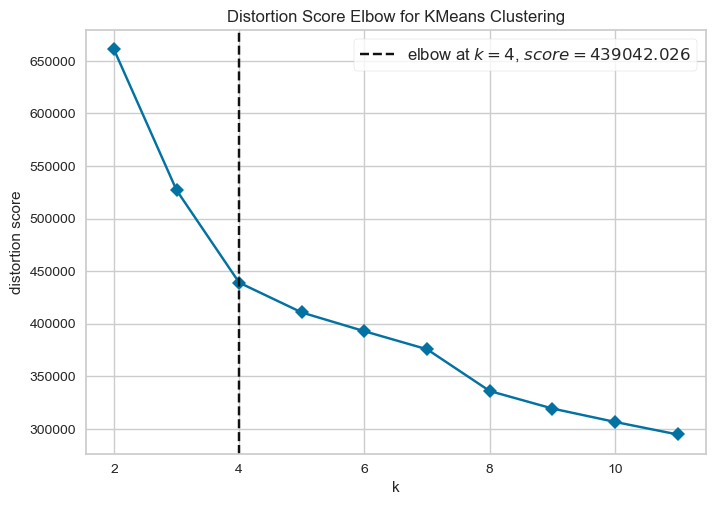

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [7]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.preprocessing import StandardScaler

# Drop rows with missing data points
df_clean = df.dropna()

# Selected features for clustering
features = ['MinimumWindDirection', 'MaximumWindDirection', 'MinimumWindSpeed', 'AverageWindSpeed', 'GustWindSpeed', 'AirTemperature', 'RelativeHumidity', 'AtmosphericPressure', 'PM25', 'PM10', 'Noise']

X = df_clean[features]

# Normalise data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KElbowVisualizer to find optimal clusters
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2, 12), metric='distortion', timings=False)

visualizer.fit(X_scaled)
visualizer.show()

**b. Is it possible to reduce the number of features used in a clustering model while
still maintaining informative clusters? If so, what are some techniques we can use
to achieve this without losing significant information?**

**To answer the question:** Yes, we can reduce the number of features used in a clustering model while still maintaining informative clusters.

Below we have applied Principle Component Analysis (PCA) to reduce the dimensionality of the dataset.

**Variance Ratio:**
We fist calculated the explained variance ration for each principle component, this tells us the total data variance that is captured by each component. The first 2 components made up 55.7% of all variance in the dataset.

**Feature Reduction with PCA:**
By applying PCA with 2 components, we reduced the number of features from 12 to 2, while still retaining most of the information (~55.7% of total variance), with just 2 features we can now visualise the data in a 2D scatterplot.

Explained Variance as Percentages: [32.04 21.95]
Reduced data shape with 2 components: (72635, 2)


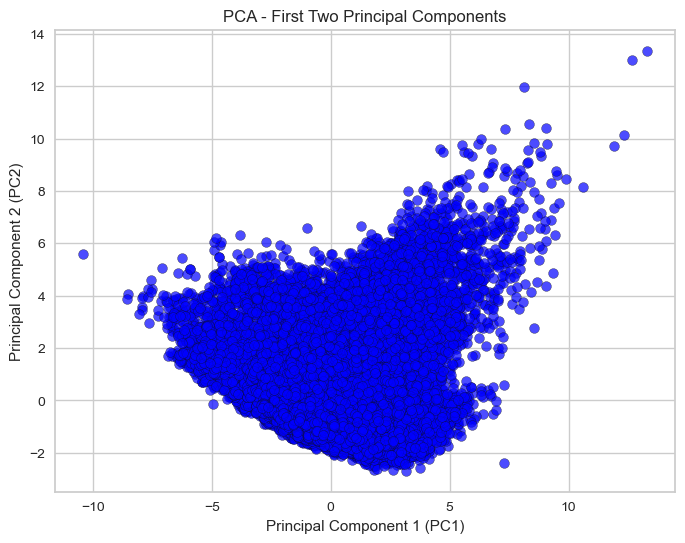

In [11]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Apply PCA with 2 components
pca = PCA(n_components=2)

# Fit PCA on the scaled data and transform
X_reduced = pca.fit_transform(X_scaled)

# Check the explained variance ratio
var = pca.explained_variance_ratio_

# Round the variance to 4 decimals
var_rounded = np.round(var, 4)

# Convert the decimal ratio to percentage
var_percent = var_rounded * 100

print("Explained Variance as Percentages:", var_percent)

# Check the shape of the reduced dataset
print("Reduced data shape with 2 components:", X_reduced.shape)

# 2D Scatter Plot of the first two principal components
plt.figure(figsize=(8, 6))

# Scatter plot, using first two principal components
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c='blue', edgecolor='k', s=50, alpha=0.7)

# Labels and title
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('PCA - First Two Principal Components')

# Show the plot
plt.show()

**c. Find out optimal number of groups, report the outcome and justify your findings.**

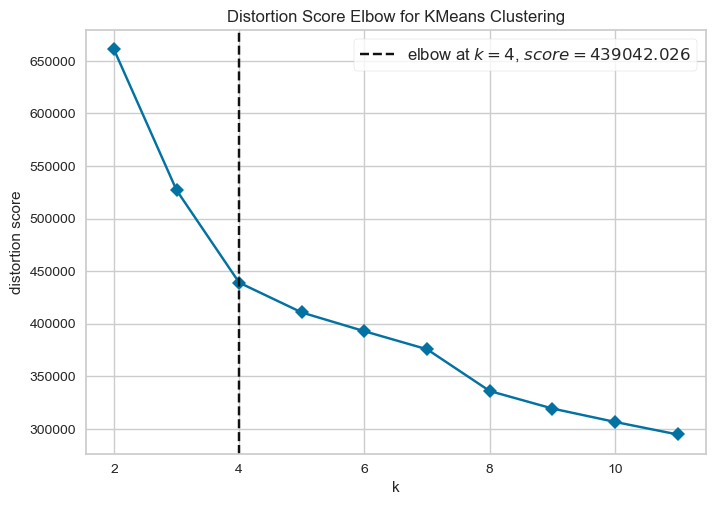

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [14]:
# KElbowVisualizer to find optimal clusters
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2, 12), metric='distortion', timings=False)

visualizer.fit(X_scaled)
visualizer.show()

Again I refer to the elbow method for determining the optimal number of clusters. The elbow method is a technique that evaluates the within-cluster sum of squares (WCSS) on the y-axis against various values of K on the x-axis. In our analysis, the Elbow Method indicated that the optimal number of clusters is 5, as beyond this point the inertia of the slope starts to decrease more slowly creating the 'elbow' point.

**2. Implement two alternative solutions of Q1 (c), except Kmeans/Kmeans++ and Shape-based clustering. Compare and report the findings.**

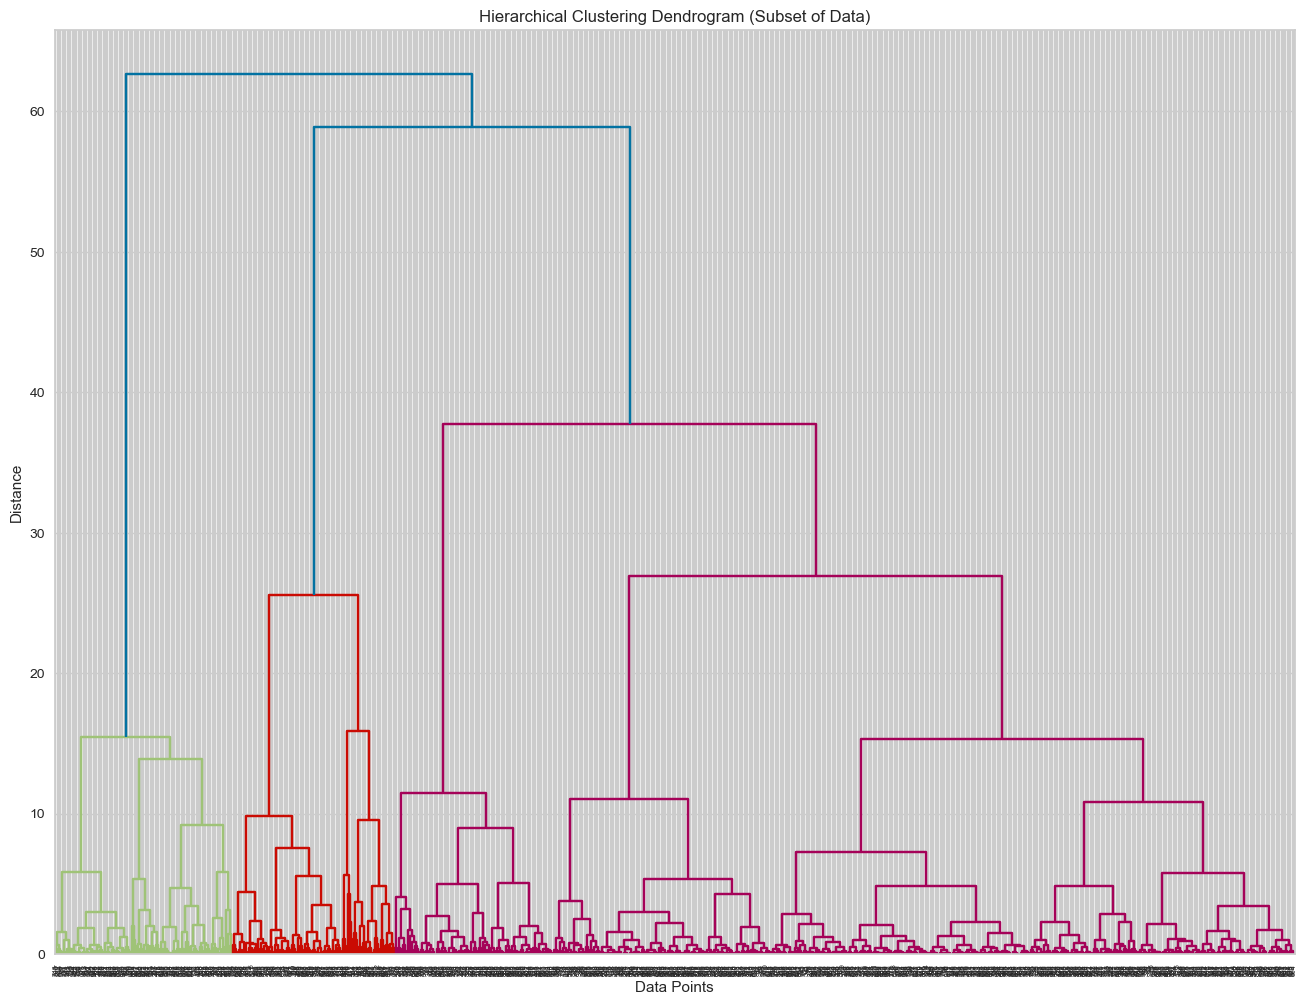

Hierarchical Clustering Silhouette Score (Subset of Data): 0.3998


In [17]:
# Hierarchical Solution

import scipy.cluster.hierarchy as hier
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import confusion_matrix
from sklearn.metrics import silhouette_score

# Sample 1000 data points
sample_size = 1000
if X_reduced.shape[0] > sample_size:
    np.random.seed(42)
    sample_indices = np.random.choice(X_reduced.shape[0], sample_size, replace=False)
    X_sample = X_reduced[sample_indices, :]
else:
    X_sample = X_reduced

# Change figure size
plt.figure(figsize=(16, 12))

# Fit the hierarchical graph
hierarchical_graph = hier.dendrogram(hier.linkage(X_sample, method='ward'))
plt.title('Hierarchical Clustering Dendrogram (Subset of Data)')
plt.xlabel('Data Points')
plt.ylabel('Distance')

plt.show()

# Perform Agglomerative Clustering using Ward's method and 4 clusters
model = AgglomerativeClustering(n_clusters=4, linkage="ward")
y_pred = model.fit_predict(X_sample)

# Calculate and print the Silhouette Score for the subset
silhouette_avg = silhouette_score(X_sample, y_pred)
print(f"Hierarchical Clustering Silhouette Score (Subset of Data): {silhouette_avg:.4f}")

In [20]:
# Gaussian Mixture Models (GMM) Solution:

from sklearn.mixture import GaussianMixture

# Set up a list to store the silhouette scores for each number of clusters
sil_scores = []

# Testing number of clusters 2 - 10
for n in range(2, 11):
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm_labels = gmm.fit_predict(X_scaled)
    
    # Calculate silhouette Score
    sil_score = silhouette_score(X_scaled, gmm_labels)
    sil_scores.append(sil_score)
    
    # Print the silhouette score for each number of clusters
    print(f"For n_components={n}, Silhouette Score: {sil_score:.4f}")

For n_components=2, Silhouette Score: 0.2303
For n_components=3, Silhouette Score: 0.1549
For n_components=4, Silhouette Score: 0.1014
For n_components=5, Silhouette Score: 0.0959
For n_components=6, Silhouette Score: 0.0675
For n_components=7, Silhouette Score: 0.0461
For n_components=8, Silhouette Score: 0.0257
For n_components=9, Silhouette Score: 0.0444
For n_components=10, Silhouette Score: 0.0167


**Comparing Results For Optimal Number of Groups:**

**Elbow Method:** 
The optimal number of clusters using the Elbow method was 5.
The elbow method showed a clear 'elbow' at 5 clusters.

**Hierarchical Solution:**
The optimal number of clusters using the Hierarchical solution was 4, however this was with a reduced sample size of 1000, to save on computing power.
From the dendrogram, 4 clusters were identified based on the largest vertical distances between merges.

**GMM Solution:**
The optimal number of clusters using the GMM solution was 2.
Using a trial and error of silhouette scores 2 clusters was found to have the highest rating when compared to all other cluster options between 2-10.

**3. Implement two alternative solutions of Q1 (c) using Shape-based clustering. Compare and report the findings.**

In [23]:
# DBSCAN Solution

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Apply DBSCAN to the reduced data
dbscan = DBSCAN(eps=0.3, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_reduced)

# Silhouette Score
dbscan_silhouette = silhouette_score(X_reduced, dbscan_labels)
print(f"DBSCAN Silhouette Score: {dbscan_silhouette}")

# Count the number of clusters (excluding noise)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"Number of clusters found by DBSCAN (excluding noise): {n_clusters}")

DBSCAN Silhouette Score: 0.652218161495449
Number of clusters found by DBSCAN (excluding noise): 2


In [24]:
# Optics Solution

from sklearn.cluster import OPTICS

# Apply OPTICS to the reduced data
optics = OPTICS(min_samples=10)
optics_labels = optics.fit_predict(X_reduced)

# Silhouette Score
optics_silhouette = silhouette_score(X_reduced, optics_labels)
print(f"OPTICS Silhouette Score: {optics_silhouette}")

# Count the number of clusters (excluding noise)
n_clusters_optics = len(set(optics_labels)) - (1 if -1 in optics_labels else 0)
print(f"Number of clusters found by OPTICS (excluding noise): {n_clusters_optics}")

OPTICS Silhouette Score: -0.4801028740455765
Number of clusters found by OPTICS (excluding noise): 1402


**4. Evaluate quality of the groupings that you have reported as a solution of Q1 (c), Q2 and Q3. Based on the evaluation outcomes, report the best solution and explain the results.**

The quality of the groupings found in Q1(c), Q2 and Q3 can be evaluated using the **Silhouette Score**, **purity Score** and the number of clusters formed and the overall coherence of the clusters.

**Elbow method:**
The elbow method identified 5 clusters as the optimal, in the scatterplot there is a clear point where the intertia drops off ('elbow'), making it easy to identify the number of clusters according to the Elbow method. The elbow method is an easy non-complicated method of finding the optimal number of clusters, however, there is no direct measure of cluster quality i.e. Silhouette Score, that can help us decide if it is the right choice.

**Hierarchical Solution:**
The Hierarchical solution determined that there were 4 clusters from the dendrogram, when considering a smaller sample size of 1000 data points. The silhouette score was 0.400, indicating a moderate level of cluster cohesion and separation.

**GMM Solution:**
In the GMM solution we evaluated different number of clusters using the silhouette score. We found that the optimal number of clusters via trial and error was found to be 2, as it showed the highest silhouette score of 0.230. 

**DBSCAN Solution:**
The DBSCAN solution identifed 2 clusters with a silhouette score of 0.652 which indicates good clustering performance. DBSCAN is particularly good for handling randomly shaped clusters and handling noise, this is why it performed resonabile well in this case.

**Optics Solution:**
Optics, unlike DBSCAN identified a large number of clusters being 1410 and the silhouette score was much lower at -0.476, indicating poor clustering performance. 

**Best Solution:**
Overall the best solution was found to be the DBSCAN solution as it identifed a reasonable number of clusters being 2 and achieved the highest silhouette score of 0.652, indicating a moderate performance.

**5. Quantify and print the relationship among independent variables of this dataset. Develop a visually presentable clustering solution for the given dataset and display using appropriate plot.**

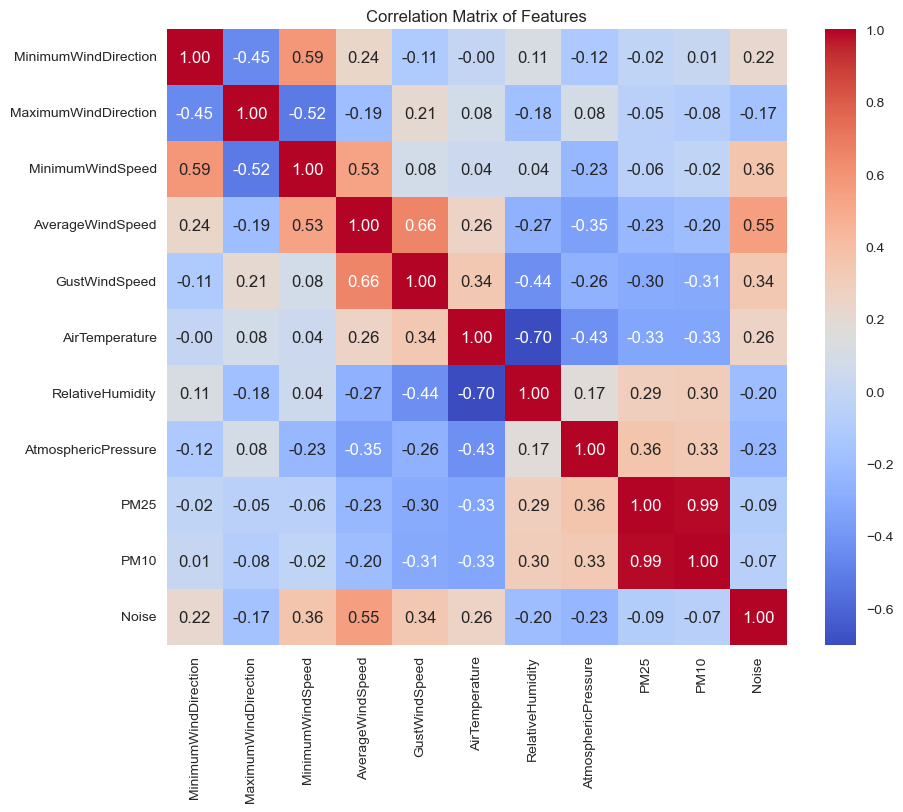

Silhouette Score for KMeans with 2 clusters: 0.2500


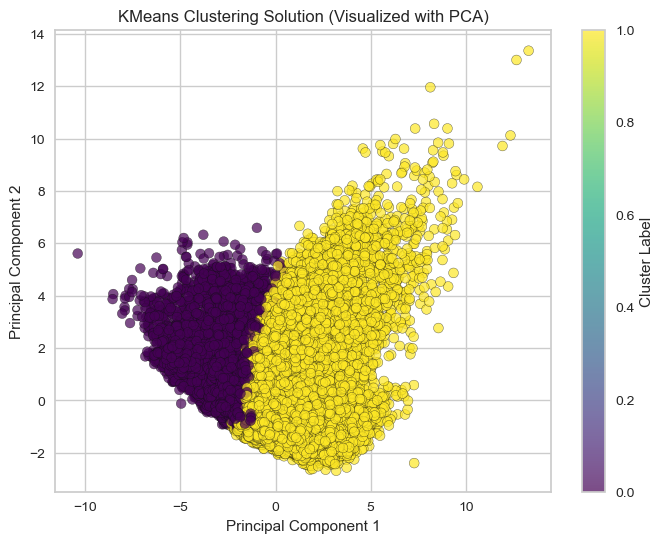

In [42]:
import seaborn as sns

# Measure closeness of feature variables
correlation_matrix = X.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

# Apply KMeans with 2 clusters (as per DBSCAN findings)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Calculate the silhouette score for the KMeans clustering solution
silhouette_avg_kmeans = silhouette_score(X_scaled, kmeans_labels)
print(f"Silhouette Score for KMeans with 2 clusters: {silhouette_avg_kmeans:.4f}")

# Plot the clustering result
plt.figure(figsize=(8, 6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=kmeans_labels, cmap='viridis', edgecolor='k', s=50, alpha=0.7)
plt.title('KMeans Clustering Solution (Visualized with PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

**6. Is there any differences in the quality of the clustering solutions produced in Q3, Q4 and Q5? Explain your findings with evidence.**

In Q3 and Q4, two different shape-based clustering methods were applied being DBSCAN and Optics. These are both non-parametric methods meaning they are used when data does not follow a normal distrubtion. DBSCAN was found to perform very well identifiying 2 clusters with a silhouette score of 0.652. Where the Optics much less so with 1410 clusters and a silhouette score of -0.480.

In Q5 a different method of KMeans clustering was applied to the PCA-reduced dataset based on the DBSCAN results of clusters. It was found to have a silhouette score of 0.25, indicating poor clustering performance. 

In summary, DBSCAN was the better performing clustering method in this analysis, this is likely due to the nature of the method excelling when data appears to have a random distribution. Unlike KMeans which is best when clusters have a spherical shape.